<a href="https://colab.research.google.com/github/richayanamandra/Agentic-AI-Loan-Approval-Chatbot/blob/main/genAI_Lab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install torch torchvision tqdm matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torchvision.utils import make_grid
from torch.utils.data import DataLoader
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
latent_dim = 100
batch_size = 128
image_size = 64
epochs = 10
lr = 0.0002
beta1 = 0.5

In [4]:
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

In [5]:
dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

print("Dataset size:", len(dataset))

100%|██████████| 170M/170M [00:06<00:00, 27.1MB/s]


Dataset size: 50000


In [6]:
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.main = nn.Sequential(

            nn.ConvTranspose2d(latent_dim,512,4,1,0,bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512,256,4,2,1,bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256,128,4,2,1,bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128,64,4,2,1,bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64,3,4,2,1,bias=False),
            nn.Tanh()
        )

    def forward(self,x):
        return self.main(x)

In [7]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.main = nn.Sequential(

            nn.Conv2d(3,64,4,2,1,bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64,128,4,2,1,bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128,256,4,2,1,bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256,512,4,2,1,bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512,1,4,1,0,bias=False),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.main(x)

In [8]:
G = Generator().to(device)
D = Discriminator().to(device)

print(G)
print(D)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)


In [9]:
criterion = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=lr, betas=(beta1,0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(beta1,0.999))

In [10]:
for epoch in range(epochs):

    for real,_ in tqdm(dataloader):

        real = real.to(device)
        batch_size = real.size(0)

        real_labels = torch.ones(batch_size, device=device)
        fake_labels = torch.zeros(batch_size, device=device)

        # -------------------
        # Train Discriminator
        # -------------------

        opt_D.zero_grad()

        real_output = D(real).view(-1)
        loss_real = criterion(real_output, real_labels)

        z = torch.randn(batch_size,latent_dim,1,1, device=device)
        fake = G(z)

        fake_output = D(fake.detach()).view(-1)
        loss_fake = criterion(fake_output, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()

        opt_D.step()

        # -------------------
        # Train Generator
        # -------------------

        opt_G.zero_grad()

        output = D(fake).view(-1)
        loss_G = criterion(output, real_labels)

        loss_G.backward()
        opt_G.step()

    print(f"Epoch [{epoch+1}/{epochs}]  Loss D: {loss_D:.4f}  Loss G: {loss_G:.4f}")

100%|██████████| 391/391 [00:59<00:00,  6.63it/s]


Epoch [1/10]  Loss D: 0.8525  Loss G: 2.1009


100%|██████████| 391/391 [01:02<00:00,  6.30it/s]


Epoch [2/10]  Loss D: 1.0546  Loss G: 5.6846


100%|██████████| 391/391 [01:02<00:00,  6.21it/s]


...

Epoch [8/10]  Loss D: 0.0008  Loss G: 8.0943


100%|██████████| 391/391 [01:03<00:00,  6.17it/s]


Epoch [9/10]  Loss D: 0.2139  Loss G: 3.6043


100%|██████████| 391/391 [01:03<00:00,  6.17it/s]

Epoch [10/10]  Loss D: 0.0146  Loss G: 5.2575


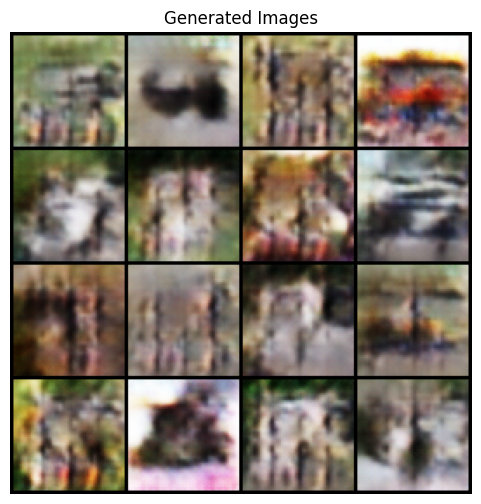

In [11]:
G.eval()

z = torch.randn(16,latent_dim,1,1, device=device)

with torch.no_grad():
    samples = G(z).cpu()

grid = make_grid(samples, nrow=4, normalize=True)

plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid,(1,2,0)))
plt.axis("off")
plt.title("Generated Images")
plt.show()

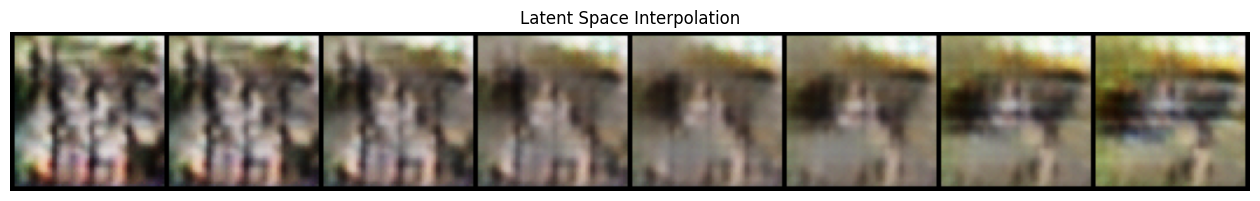

In [12]:
z1 = torch.randn(1,latent_dim,1,1, device=device)
z2 = torch.randn(1,latent_dim,1,1, device=device)

alphas = torch.linspace(0,1,8)

images = []

with torch.no_grad():

    for a in alphas:
        z = (1-a)*z1 + a*z2
        img = G(z)
        images.append(img)

images = torch.cat(images).cpu()

grid = make_grid(images, nrow=8, normalize=True)

plt.figure(figsize=(16,3))
plt.imshow(np.transpose(grid,(1,2,0)))
plt.axis("off")
plt.title("Latent Space Interpolation")
plt.show()